In [ ]:
import pandas as pd

# Importing the csv file

In [9]:
df = pd.read_csv('train.csv')

# General view for the data

In [10]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Dropping the un necessary columns

In [14]:
try:
    df.drop(['PassengerId','Name','Ticket'] , axis=1 , inplace=True)
except Exception as e:
    print('axis already dropped')
df.head()

axis already dropped


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,male,22.0,1,0,7.2500,NaN,S
1,1,1,female,38.0,1,0,71.2833,C85,C
2,1,3,female,26.0,0,0,7.9250,NaN,S
3,1,1,female,35.0,1,0,53.1000,C123,S
4,0,3,male,35.0,0,0,8.0500,NaN,S


In [20]:
dtypes = df.dtypes
n_unique = df.nunique()

pd.DataFrame({
    'Dtypes': dtypes,
    'No. of Unqiue Values': n_unique
}).T



,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
Dtypes,int64,int64,object,float64,int64,int64,float64,object,object
No. of Unqiue Values,2,3,2,88,7,7,248,147,3


## Adjusting the DataTypes

In [22]:
def data_checker(dataframe):
    data_types = dataframe.dtypes
    unique_values = dataframe.nunique()

    return pd.DataFrame({
    'Dtypes': data_types,
    'No. of Unqiue Values': unique_values
}).T



In [24]:
data_checker(dataframe=df)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
Dtypes,int64,int64,object,float64,int64,int64,float64,object,object
No. of Unqiue Values,2,3,2,88,7,7,248,147,3


In [27]:
cols= ['Survived','Pclass','Sex','SibSp','Parch','Embarked']
df[cols] = df[cols].astype('category')

data_checker(df)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
Dtypes,category,category,category,float64,category,category,float64,object,category
No. of Unqiue Values,2,3,2,88,7,7,248,147,3


## Checking the Nulls 

In [88]:
def check_nulls(dataframe):
    null = dataframe.isnull().sum()
    ratio = null / df.shape[0]
    return pd.DataFrame({
        'Count of Null Values': null,
        "Null Ratio": ratio
    }).T


check_nulls(df)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
Count of Null Values,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Null Ratio,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [46]:
try:
    df = df.dropna(subset=["Embarked"])
except Exception as e:
    print("already dropped")


In [47]:
try:
    df = df.drop('Cabin' , axis=1)
except Exception as e:
    print("already dropped")


already dropped


In [50]:
age_median = df['Age'].median()
df['Age'].fillna(age_median , inplace=True)



C:\Users\Ahmed\AppData\Local\Temp\ipykernel_7116\1406266124.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(age_median , inplace=True)


In [51]:
check_nulls(df)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
Count of Null Values,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Null Ratio,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Handling the Outliers

In [53]:
df.describe()

,Age,Fare
count,889.000000,889.000000
mean,29.315152,32.096681
std,12.984932,49.697504
min,0.420000,0.000000
25%,22.000000,7.895800
50%,28.000000,14.454200
75%,35.000000,31.000000
max,80.000000,512.329200


In [54]:
import matplotlib.pyplot as plt
import seaborn as sns


I is 0 , col is Age
Age
I is 1 , col is Fare
Fare


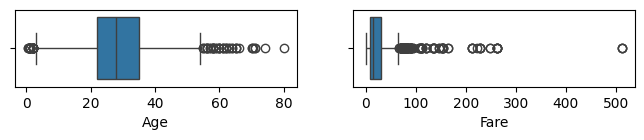

In [65]:
nums_cols = df.select_dtypes('number').columns

plt.figure(figsize=(8,1))

for i,col in enumerate(nums_cols):
    print(f"I is {i} , col is {col}")
    print(nums_cols[i])
    plt.subplot(1,2,i+1)
    sns.boxplot(df[col],orient='h')
    

In [83]:
def iqr_outlier_handler(dataframe, inplace: bool = True):

    nums_cols = dataframe.select_dtypes("number").columns
    for col in nums_cols:
        Q1 = dataframe[col].quantile(0.25)
        Q3 = dataframe[col].quantile(0.75)
        IQR = Q3 - Q1

        print("Column before cleaning:")
        print(dataframe[col].describe())

        lower_fence = Q1 - 1.5 * IQR
        upper_fence = Q3 + 1.5 * IQR

        # Boolean masks
        lower_mask = dataframe[col] < lower_fence
        upper_mask = dataframe[col] > upper_fence

        # Replace values
        if inplace:
            dataframe.loc[lower_mask, col] = lower_fence
            dataframe.loc[upper_mask, col] = upper_fence
        else:
            dataframe = dataframe.copy()
            dataframe.loc[lower_mask, col] = lower_fence
            dataframe.loc[upper_mask, col] = upper_fence

        print("Column after cleaning:")
        print(dataframe[col].describe())

        print(
            f"Col: {col}, Q1={Q1}, Q3={Q3}, IQR={IQR}, "
            f"Lower Fence={lower_fence}, Upper Fence={upper_fence}, "
            f"Lower Outliers={lower_mask.sum()}, Upper Outliers={upper_mask.sum()}"
        )

        print(f"Now the data of column '{col}' is cleaned and ready for analysis.")

    return dataframe if not inplace else None


In [86]:
iqr_outlier_handler(df , inplace=True)

Column before cleaning:
count    889.000000
mean      29.000562
std       12.051609
min        2.500000
25%       22.000000
50%       28.000000
75%       35.000000
max       54.500000
Name: Age, dtype: float64
Column after cleaning:
count    889.000000
mean      29.000562
std       12.051609
min        2.500000
25%       22.000000
50%       28.000000
75%       35.000000
max       54.500000
Name: Age, dtype: float64
Col: Age, Q1=22.0, Q3=35.0, IQR=13.0, Lower Fence=2.5, Upper Fence=54.5, Lower Outliers=0, Upper Outliers=0
Now the data of column 'Age' is cleaned and ready for analysis.
Column before cleaning:
count    889.000000
mean      23.956061
std       20.414997
min        0.000000
25%        7.895800
50%       14.454200
75%       31.000000
max       65.656300
Name: Fare, dtype: float64
Column after cleaning:
count    889.000000
mean      23.956061
std       20.414997
min        0.000000
25%        7.895800
50%       14.454200
75%       31.000000
max       65.656300
Name: Fare, dty

I is 0 , col is Age
Age
I is 1 , col is Fare
Fare


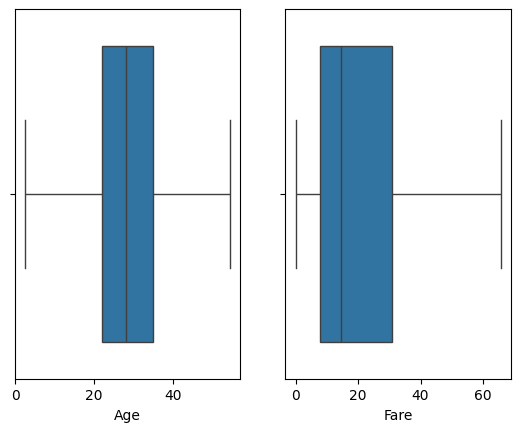

In [87]:
for i,col in enumerate(nums_cols):
    print(f"I is {i} , col is {col}")
    print(nums_cols[i])
    plt.subplot(1,2,i+1)
    sns.boxplot(df[col],orient='h')